In [1]:
from datetime import datetime, timedelta, timezone
import random

# Window: 4 years back -> 2 years forward from today (ADR-018)
WINDOW_START = datetime(2022, 6, 1, tzinfo=timezone.utc)
WINDOW_END   = datetime(2028, 6, 1, tzinfo=timezone.utc)

# Seasonal weights -- identical to simulator/generator.py _MONTHLY_WEIGHT
_MONTHLY_WEIGHT = {
    1: 0.65, 2: 0.70, 3: 0.90, 4: 0.95,  5: 1.00,
    6: 1.05, 7: 1.10, 8: 1.05, 9: 1.00, 10: 1.10,
    11: 1.80, 12: 2.50,
}

def _seasonal_weight(dt):
    base = _MONTHLY_WEIGHT[dt.month]
    if dt.month == 12:
        if dt.day <= 15:   base *= 1.5
        elif dt.day <= 24: base *= 1.1
        else:              base *= 0.6
    return base

def _build_day_pool(start, end):
    days, weights = [], []
    cur = start.replace(hour=0, minute=0, second=0, microsecond=0)
    while cur < end:
        days.append(cur)
        weights.append(_seasonal_weight(cur))
        cur += timedelta(days=1)
    return days, weights

def _sample_dates_seasonal(n, start, end):
    days, weights = _build_day_pool(start, end)
    chosen = random.choices(days, weights=weights, k=n)
    return [d + timedelta(seconds=random.randint(0, 86_399)) for d in chosen]

def _sample_dates_blended(n, start, end, blend=0.5):
    """blend=0.5 -> equal mix seasonal + uniform. For household members."""
    days, seasonal_w = _build_day_pool(start, end)
    if not days:
        return [start] * n
    max_w = max(seasonal_w)
    blended_w = [blend * s + (1 - blend) * max_w for s in seasonal_w]
    chosen = random.choices(days, weights=blended_w, k=n)
    return [d + timedelta(seconds=random.randint(0, 86_399)) for d in chosen]

print(f'Window: {WINDOW_START.date()} -> {WINDOW_END.date()}  ({(WINDOW_END - WINDOW_START).days} days)')


Window: 2022-06-01 -> 2028-06-01  (2192 days)


In [27]:
def x_sample_dates_blended(n, start, end, blend=0.5):
    """blend=0.5 -> equal mix seasonal + uniform. For household members."""
    days, seasonal_w = _build_day_pool(start, end)
    if not days:
        return [start] * n
    max_w = max(seasonal_w)
    blended_w = [blend * s + (1 - blend) * max_w for s in seasonal_w]
    return days, blended_w
    chosen = random.choices(days, weights=blended_w, k=n)
    return [d + timedelta(seconds=random.randint(0, 86_399)) for d in chosen]

start = datetime(2027, 7, 4, tzinfo=timezone.utc)
end = WINDOW_END
r = x_sample_dates_blended(1, start, end)

In [28]:
d.append(r)

In [22]:
import pandas as pd
import matplotlib.pyplot as plt

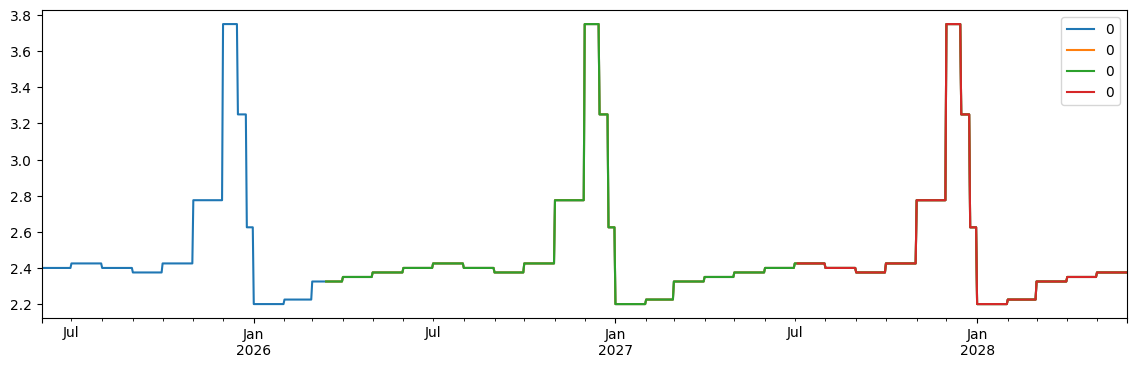

In [29]:
fig, ax = plt.subplots(figsize=(14,4))
for r in d:
    pd.Series(index=r[0],data=r[1]).to_frame().plot(ax=ax)